In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Càrrega
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Train: (1460, 81)
Test:  (1459, 80)


In [2]:
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


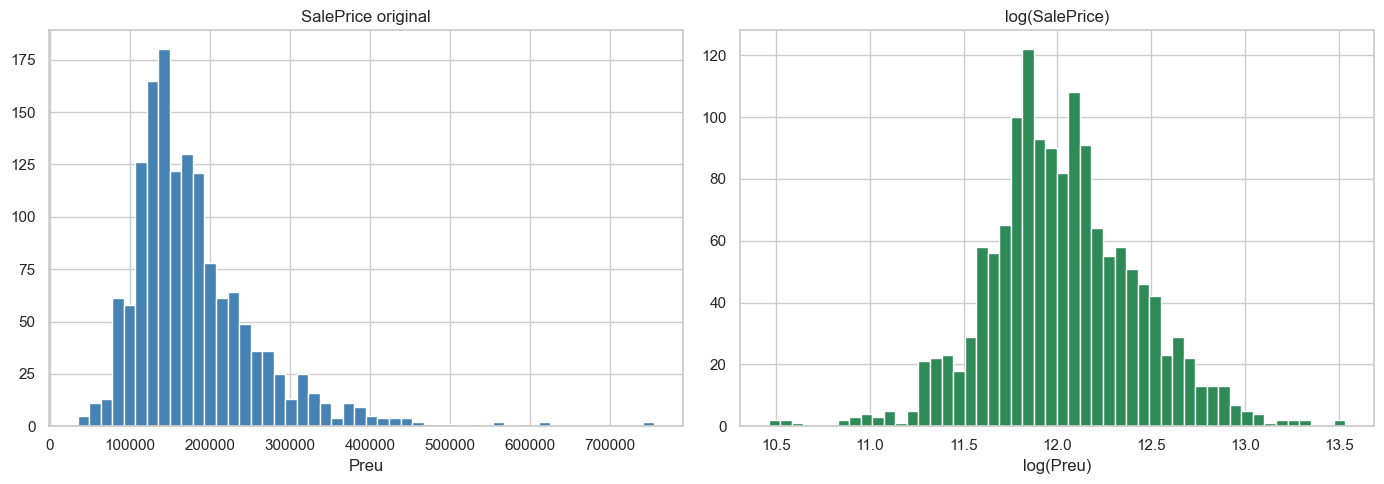

Skewness original: 1.88
Skewness log:      0.12


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original — veuràs skew
train['SalePrice'].hist(bins=50, ax=ax1, color='steelblue')
ax1.set_title('SalePrice original')
ax1.set_xlabel('Preu')

# Log — molt més normal
np.log1p(train['SalePrice']).hist(bins=50, ax=ax2, color='seagreen')
ax2.set_title('log(SalePrice)')
ax2.set_xlabel('log(Preu)')

plt.tight_layout()
plt.show()

print(f"Skewness original: {train['SalePrice'].skew():.2f}")
print(f"Skewness log:      {np.log1p(train['SalePrice']).skew():.2f}")

              nuls     %
PoolQC        1453  99.5
MiscFeature   1406  96.3
Alley         1369  93.8
Fence         1179  80.8
MasVnrType     872  59.7
FireplaceQu    690  47.3
LotFrontage    259  17.7
GarageType      81   5.5
GarageYrBlt     81   5.5
GarageFinish    81   5.5
GarageQual      81   5.5
GarageCond      81   5.5
BsmtFinType2    38   2.6
BsmtExposure    38   2.6
BsmtFinType1    37   2.5
BsmtCond        37   2.5
BsmtQual        37   2.5
MasVnrArea       8   0.5
Electrical       1   0.1


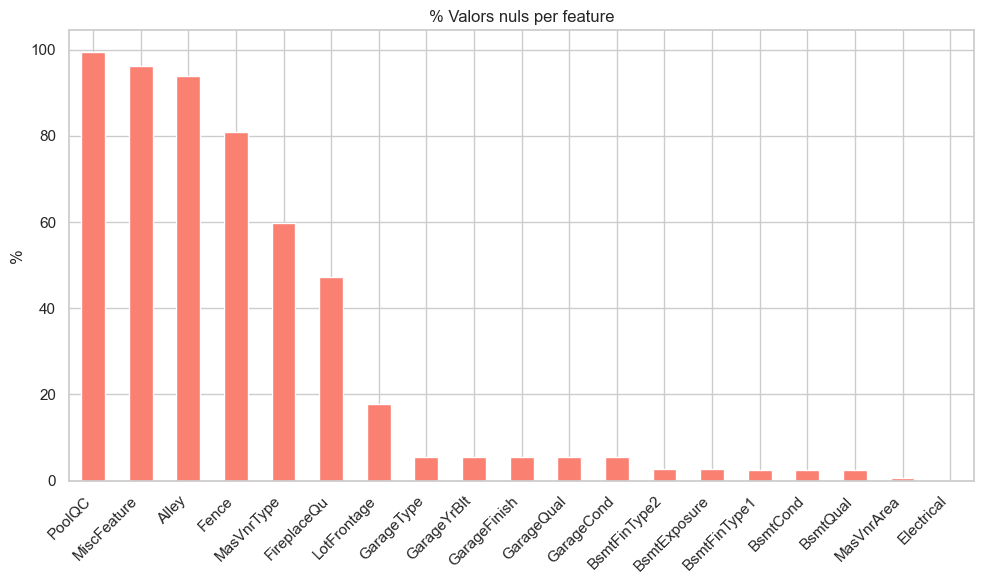

In [4]:
nulls = train.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
pct = (nulls / len(train) * 100).round(1)

null_df = pd.DataFrame({'nuls': nulls, '%': pct})
print(null_df)

# Visualització
plt.figure(figsize=(10, 6))
pct.plot(kind='bar', color='salmon')
plt.title('% Valors nuls per feature')
plt.ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

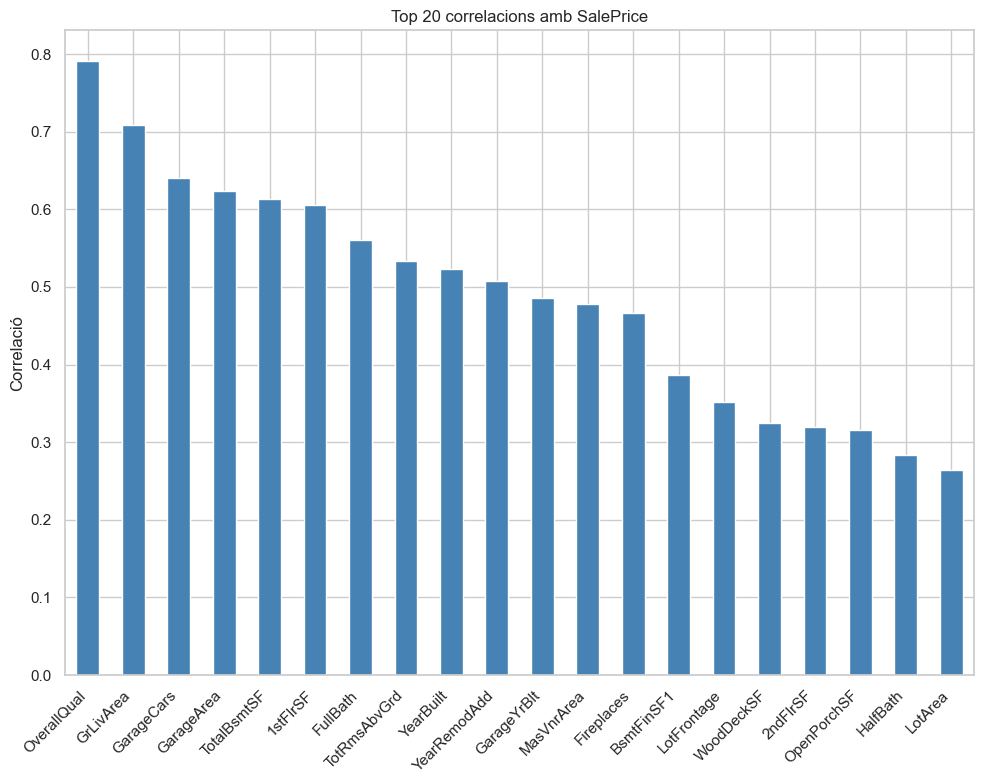

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [5]:
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr[1:21].plot(kind='bar', color='steelblue')  # top 20, excloem SalePrice mateix
plt.title('Top 20 correlacions amb SalePrice')
plt.ylabel('Correlació')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(corr[1:11])  # top 10 en text

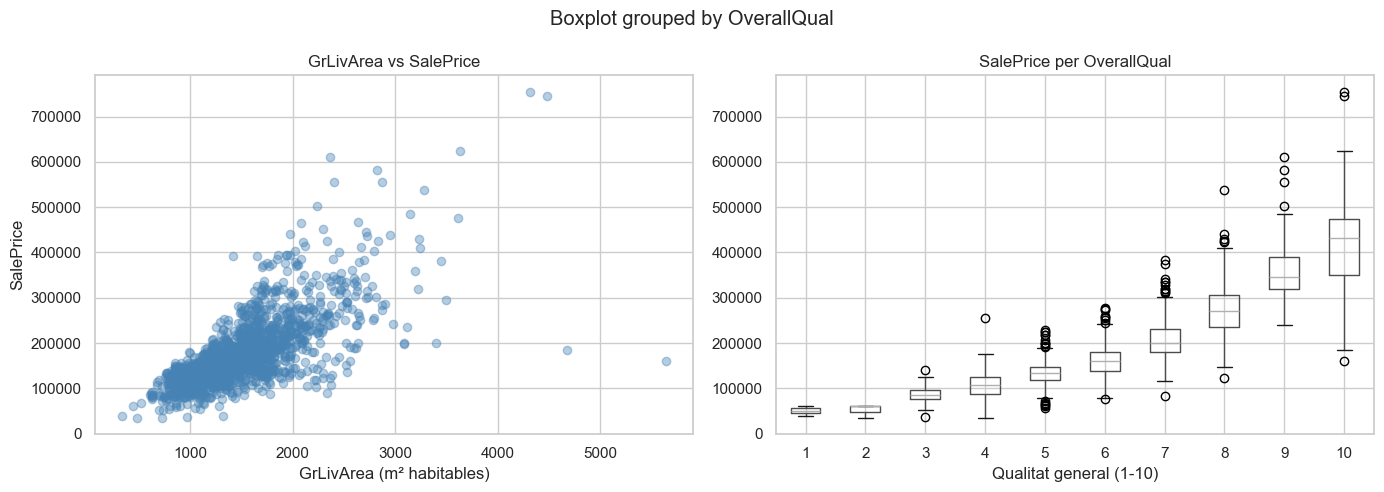

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
ax1.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')
ax1.set_xlabel('GrLivArea (m² habitables)')
ax1.set_ylabel('SalePrice')
ax1.set_title('GrLivArea vs SalePrice')

# OverallQual vs SalePrice
train.boxplot(column='SalePrice', by='OverallQual', ax=ax2)
ax2.set_title('SalePrice per OverallQual')
ax2.set_xlabel('Qualitat general (1-10)')

plt.tight_layout()
plt.show()

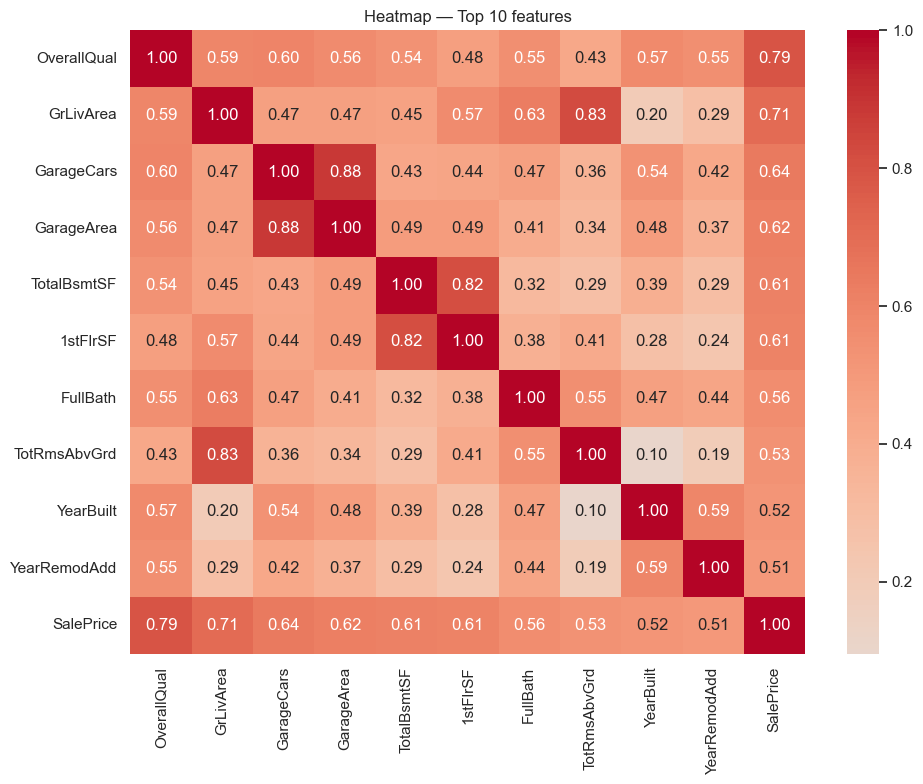

In [7]:
top_features = corr[1:11].index.tolist()  # top 10 features
top_features.append('SalePrice')

plt.figure(figsize=(10, 8))
sns.heatmap(
    train[top_features].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0
)
plt.title('Heatmap — Top 10 features')
plt.tight_layout()
plt.show()

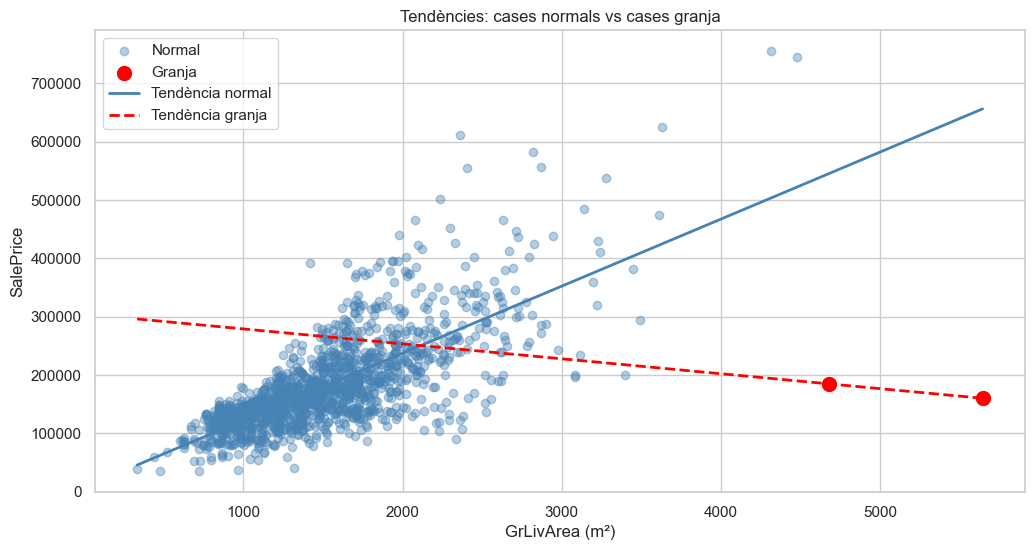

In [8]:
    # Al notebook 01, afegeix una cel·la nova
import numpy as np

# Separem cases normals i cases granja
normal = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000))]
granja = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000)]

# Línia de tendència cases normals
z_normal = np.polyfit(normal['GrLivArea'], normal['SalePrice'], 1)
p_normal = np.poly1d(z_normal)

# Línia de tendència cases granja
z_granja = np.polyfit(granja['GrLivArea'], granja['SalePrice'], 1)
p_granja = np.poly1d(z_granja)

# Gràfic
plt.figure(figsize=(12, 6))
plt.scatter(normal['GrLivArea'], normal['SalePrice'], alpha=0.4, color='steelblue', label='Normal')
plt.scatter(granja['GrLivArea'], granja['SalePrice'], color='red', s=100, label='Granja')

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
plt.plot(x_line, p_normal(x_line), color='steelblue', linewidth=2, label='Tendència normal')
plt.plot(x_line, p_granja(x_line), color='red', linewidth=2, linestyle='--', label='Tendència granja')

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Tendències: cases normals vs cases granja')
plt.legend()
plt.show()

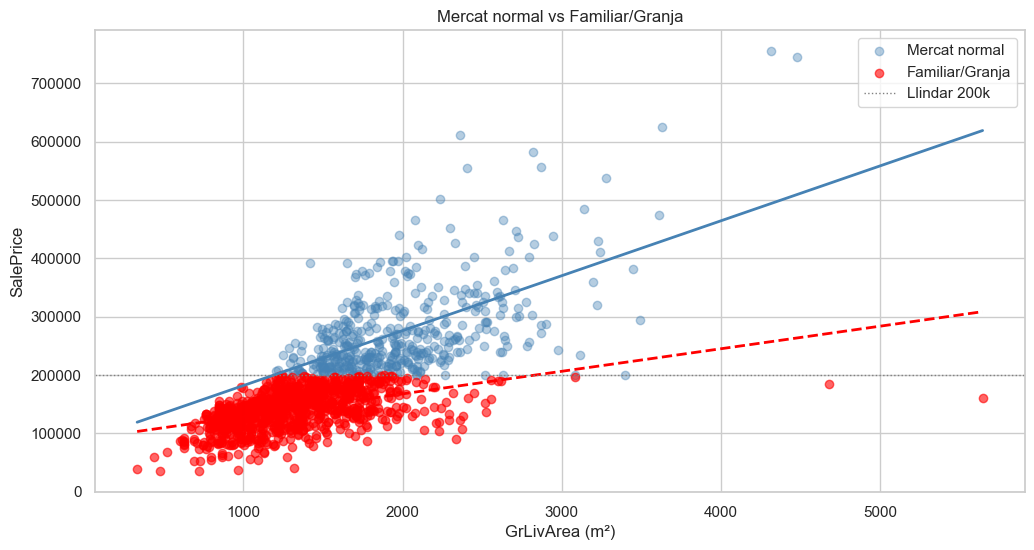

In [9]:
# Dos grups
normal  = train[train['SalePrice'] >= 200000]
familiar = train[train['SalePrice'] < 200000]

# Línies de tendència
z_normal   = np.polyfit(normal['GrLivArea'], normal['SalePrice'], 1)
z_familiar = np.polyfit(familiar['GrLivArea'], familiar['SalePrice'], 1)

p_normal   = np.poly1d(z_normal)
p_familiar = np.poly1d(z_familiar)

# Gràfic
plt.figure(figsize=(12, 6))
plt.scatter(normal['GrLivArea'], normal['SalePrice'], alpha=0.4, color='steelblue', label='Mercat normal')
plt.scatter(familiar['GrLivArea'], familiar['SalePrice'], color='red', alpha=0.6, label='Familiar/Granja')

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
plt.plot(x_line, p_normal(x_line), color='steelblue', linewidth=2)
plt.plot(x_line, p_familiar(x_line), color='red', linewidth=2, linestyle='--')

plt.axhline(y=200000, color='gray', linestyle=':', linewidth=1, label='Llindar 200k')

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Mercat normal vs Familiar/Granja')
plt.legend()
plt.show()

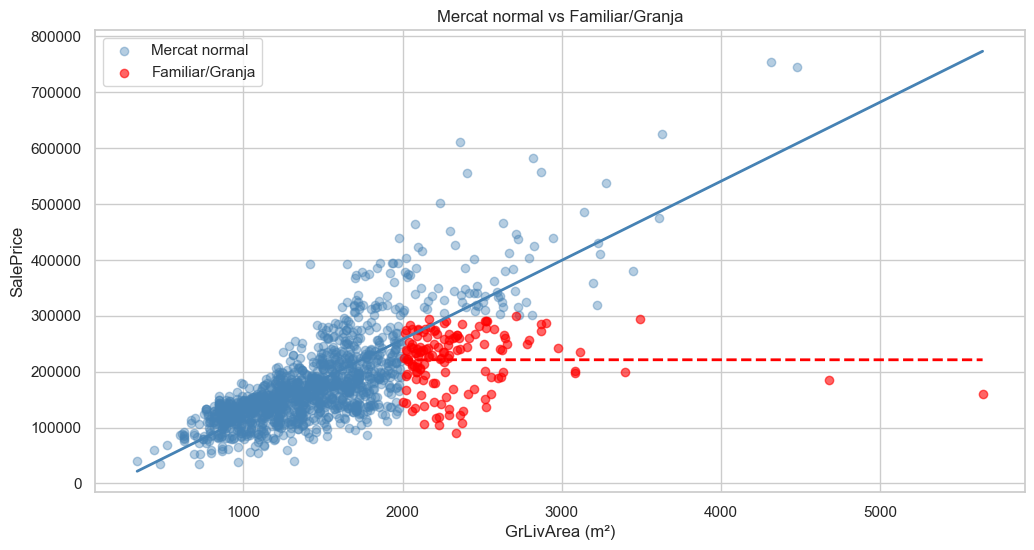

In [10]:
# Dos grups
normal   = train[~((train['GrLivArea'] > 2000) & (train['SalePrice'] < 300000))]
familiar = train[(train['GrLivArea'] > 2000) & (train['SalePrice'] < 300000)]

# Línies de tendència
z_normal   = np.polyfit(normal['GrLivArea'], normal['SalePrice'], 1)
z_familiar = np.polyfit(familiar['GrLivArea'], familiar['SalePrice'], 1)

p_normal   = np.poly1d(z_normal)
p_familiar = np.poly1d(z_familiar)

# Gràfic
plt.figure(figsize=(12, 6))
plt.scatter(normal['GrLivArea'], normal['SalePrice'], alpha=0.4, color='steelblue', label='Mercat normal')
plt.scatter(familiar['GrLivArea'], familiar['SalePrice'], color='red', alpha=0.6, label='Familiar/Granja')

# Línia familiar només a partir dels 2000m²
x_normal   = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
x_familiar = np.linspace(2000, train['GrLivArea'].max(), 100)

plt.plot(x_normal,   p_normal(x_normal),     color='steelblue', linewidth=2)
plt.plot(x_familiar, p_familiar(x_familiar), color='red', linewidth=2, linestyle='--')

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Mercat normal vs Familiar/Granja')
plt.legend()
plt.show()

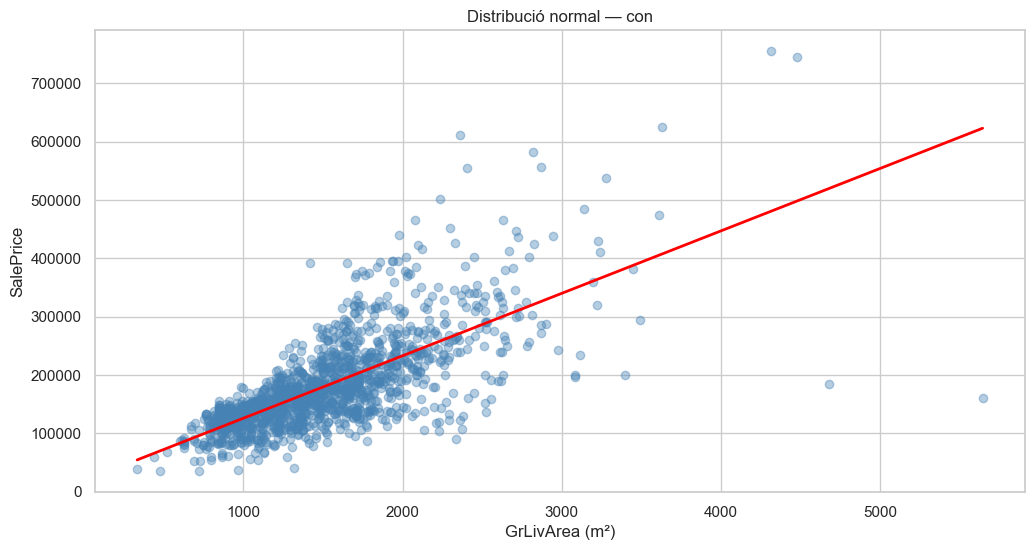

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')

# Línia de tendència del conjunt sencer
z = np.polyfit(train['GrLivArea'], train['SalePrice'], 1)
p = np.poly1d(z)

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2)

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Distribució normal — con')
plt.show()

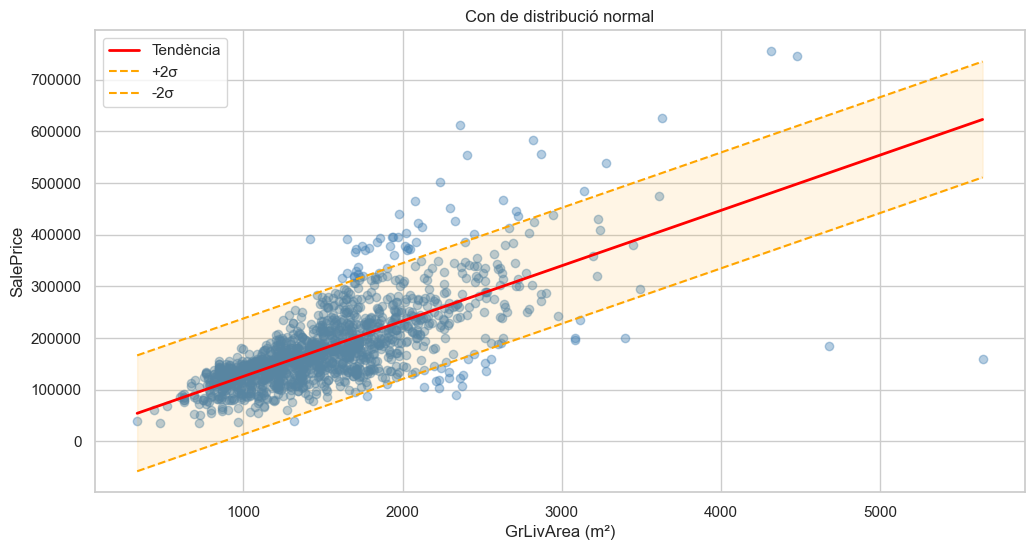

In [12]:
from numpy.polynomial.polynomial import polyfit

plt.figure(figsize=(12, 6))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')

# Línia central
z = np.polyfit(train['GrLivArea'], train['SalePrice'], 1)
p = np.poly1d(z)

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
y_pred = p(x_line)

# Càlcul dels residuals per fer el con
residuals = train['SalePrice'] - p(train['GrLivArea'])
std = residuals.std()

plt.plot(x_line, y_pred, color='red', linewidth=2, label='Tendència')
plt.plot(x_line, y_pred + 2*std, color='orange', linewidth=1.5, linestyle='--', label='+2σ')
plt.plot(x_line, y_pred - 2*std, color='orange', linewidth=1.5, linestyle='--', label='-2σ')
plt.fill_between(x_line, y_pred - 2*std, y_pred + 2*std, alpha=0.1, color='orange')

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Con de distribució normal')
plt.legend()
plt.show()


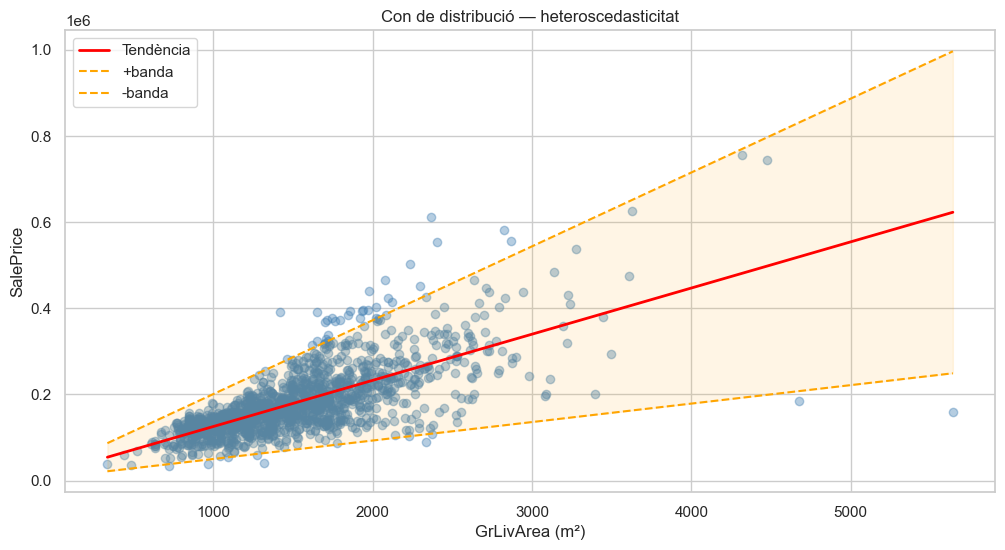

In [13]:
plt.figure(figsize=(12, 6))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')

# Línia central
z = np.polyfit(train['GrLivArea'], train['SalePrice'], 1)
p = np.poly1d(z)

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 100)
y_pred = p(x_line)

# Std que creix proporcionalment amb x — això fa el con
std_crescents = 0.60 * y_pred  # 30% del valor predit

plt.plot(x_line, y_pred, color='red', linewidth=2, label='Tendència')
plt.plot(x_line, y_pred + std_crescents, color='orange', linewidth=1.5, linestyle='--', label='+banda')
plt.plot(x_line, y_pred - std_crescents, color='orange', linewidth=1.5, linestyle='--', label='-banda')
plt.fill_between(x_line, y_pred - std_crescents, y_pred + std_crescents, alpha=0.1, color='orange')

plt.xlabel('GrLivArea (m²)')
plt.ylabel('SalePrice')
plt.title('Con de distribució — heteroscedasticitat')
plt.legend()
plt.show()

In [14]:
train[(train['GrLivArea'].between(1500, 2000)) & 
      (train['SalePrice'] > 400000)][['GrLivArea', 'SalePrice', 'Neighborhood', 'SaleCondition', 'OverallQual']]\
.sort_values('SalePrice', ascending=False)

,GrLivArea,SalePrice,Neighborhood,SaleCondition,OverallQual
473,1976,440000,NridgHt,Partial,8


In [15]:
import numpy as np

train[(train['GrLivArea'].between(1500, 2000)) & 
      (np.log1p(train['SalePrice']) > 12.8)][['GrLivArea', 'SalePrice', 'Neighborhood', 'SaleCondition', 'OverallQual']]\
.sort_values('SalePrice', ascending=False)

,GrLivArea,SalePrice,Neighborhood,SaleCondition,OverallQual
473,1976,440000,NridgHt,Partial,8
987,1940,395192,NridgHt,Partial,9
774,1973,395000,NridgHt,Partial,8
1437,1932,394617,NridgHt,Partial,8
378,1856,394432,StoneBr,Partial,9
1181,1652,392500,Crawfor,Partial,8
53,1842,385000,Veenker,Normal,9
1388,1746,377500,Gilbert,Normal,9
336,1922,377426,StoneBr,Normal,9
481,1792,374000,NridgHt,Normal,9


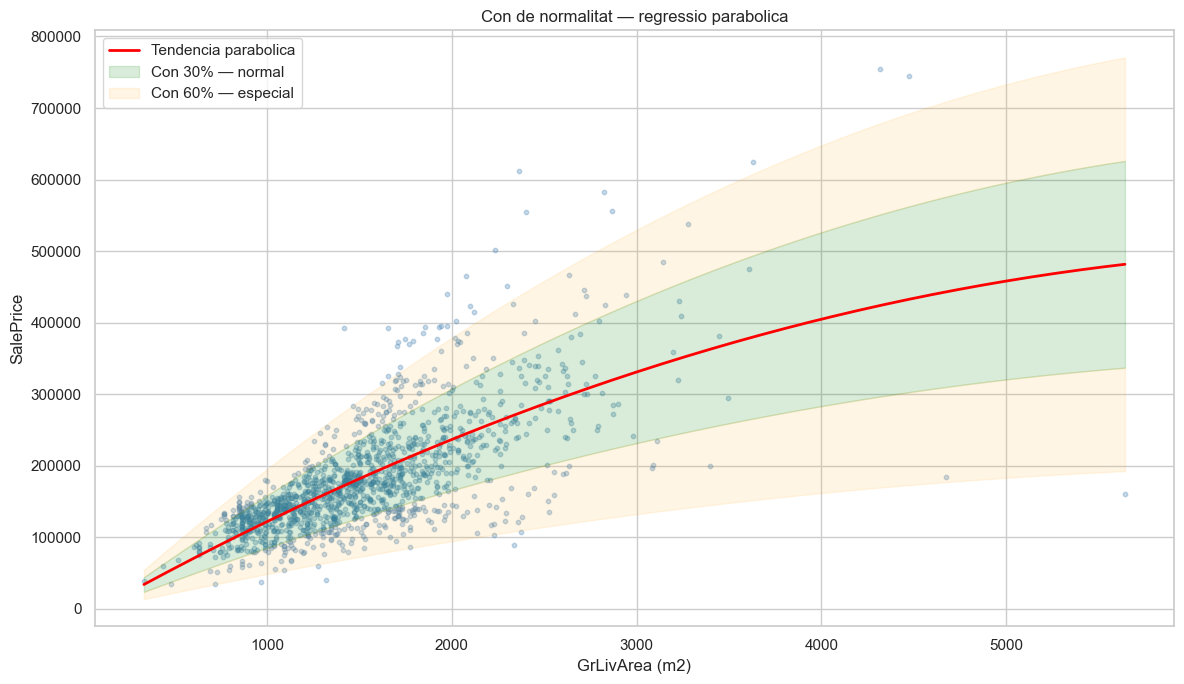

In [16]:
# Regressió parabòlica + cons de normalitat
fig, ax = plt.subplots(figsize=(12, 7))

# Dades
ax.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.3, color='steelblue', s=10)

# Regressió parabòlica
z = np.polyfit(train['GrLivArea'], train['SalePrice'], 2)
p = np.poly1d(z)

x_line = np.linspace(train['GrLivArea'].min(), train['GrLivArea'].max(), 200)
y_pred = p(x_line)

# Cons
plt.plot(x_line, y_pred, color='red', linewidth=2, label='Tendencia parabolica')
plt.fill_between(x_line, y_pred * 0.7, y_pred * 1.3, alpha=0.15, color='green', label='Con 30% — normal')
plt.fill_between(x_line, y_pred * 0.4, y_pred * 0.7, alpha=0.1, color='orange', label='Con 60% — especial')
plt.fill_between(x_line, y_pred * 1.3, y_pred * 1.6, alpha=0.1, color='orange')

ax.set_xlabel('GrLivArea (m2)')
ax.set_ylabel('SalePrice')
ax.set_title('Con de normalitat — regressio parabolica')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Quants punts hi ha a cada zona?
y_pred_train = p(train['GrLivArea'])

normal   = ((train['SalePrice'] >= y_pred_train * 0.7) & (train['SalePrice'] <= y_pred_train * 1.3))
especial = ((train['SalePrice'] >= y_pred_train * 0.4) & (train['SalePrice'] < y_pred_train * 0.7)) | \
           ((train['SalePrice'] > y_pred_train * 1.3) & (train['SalePrice'] <= y_pred_train * 1.6))
anomalia = (train['SalePrice'] < y_pred_train * 0.4) | (train['SalePrice'] > y_pred_train * 1.6)

print(f"Zona verda  (normal):   {normal.sum()} cases ({normal.mean()*100:.1f}%)")
print(f"Zona groga  (especial): {especial.sum()} cases ({especial.mean()*100:.1f}%)")
print(f"Zona roja   (anomalia): {anomalia.sum()} cases ({anomalia.mean()*100:.1f}%)")

Zona verda  (normal):   1119 cases (76.6%)
Zona groga  (especial): 303 cases (20.8%)
Zona roja   (anomalia): 38 cases (2.6%)


In [18]:
groga_baix = ((train['SalePrice'] >= y_pred_train * 0.4) & (train['SalePrice'] < y_pred_train * 0.7))
groga_dalt = ((train['SalePrice'] > y_pred_train * 1.3) & (train['SalePrice'] <= y_pred_train * 1.6))

print(f"Zona groga per BAIX: {groga_baix.sum()} cases ({groga_baix.mean()*100:.1f}%)")
print(f"Zona groga per DALT: {groga_dalt.sum()} cases ({groga_dalt.mean()*100:.1f}%)")
print(f"Ratio baix/dalt: {groga_baix.sum()/groga_dalt.sum():.2f}x")

Zona groga per BAIX: 172 cases (11.8%)
Zona groga per DALT: 131 cases (9.0%)
Ratio baix/dalt: 1.31x


In [19]:
groga_baix_df = train[groga_baix][['SalePrice', 'Neighborhood', 'SaleCondition', 'OverallQual', 'YearBuilt', 'YearRemodAdd']]
groga_baix_df['AnysSenseReforma'] = groga_baix_df['YearRemodAdd'] - groga_baix_df['YearBuilt']

print(groga_baix_df.describe())

           SalePrice  OverallQual    YearBuilt  YearRemodAdd  AnysSenseReforma
count     172.000000   172.000000   172.000000    172.000000        172.000000
mean   116831.703488     5.063953  1940.215116   1970.005814         29.790698
std     34974.182916     1.185429    28.327145     20.552741         33.229352
min     34900.000000     1.000000  1872.000000   1950.000000          0.000000
25%     91500.000000     4.000000  1918.750000   1950.000000          0.000000
50%    117250.000000     5.000000  1940.500000   1965.000000         20.000000
75%    136928.750000     6.000000  1963.000000   1990.000000         51.250000
max    235000.000000    10.000000  2007.000000   2008.000000        115.000000


In [20]:
print(train[groga_baix]['SaleCondition'].value_counts())
print(train[groga_baix]['Neighborhood'].value_counts().head(10))

SaleCondition
Normal     133
Abnorml     23
Alloca       6
Family       5
Partial      3
AdjLand      2
Name: count, dtype: int64
Neighborhood
OldTown    41
Edwards    30
NAmes      27
SWISU      15
IDOTRR     14
Sawyer      8
Crawfor     6
BrkSide     6
MeadowV     6
SawyerW     4
Name: count, dtype: int64


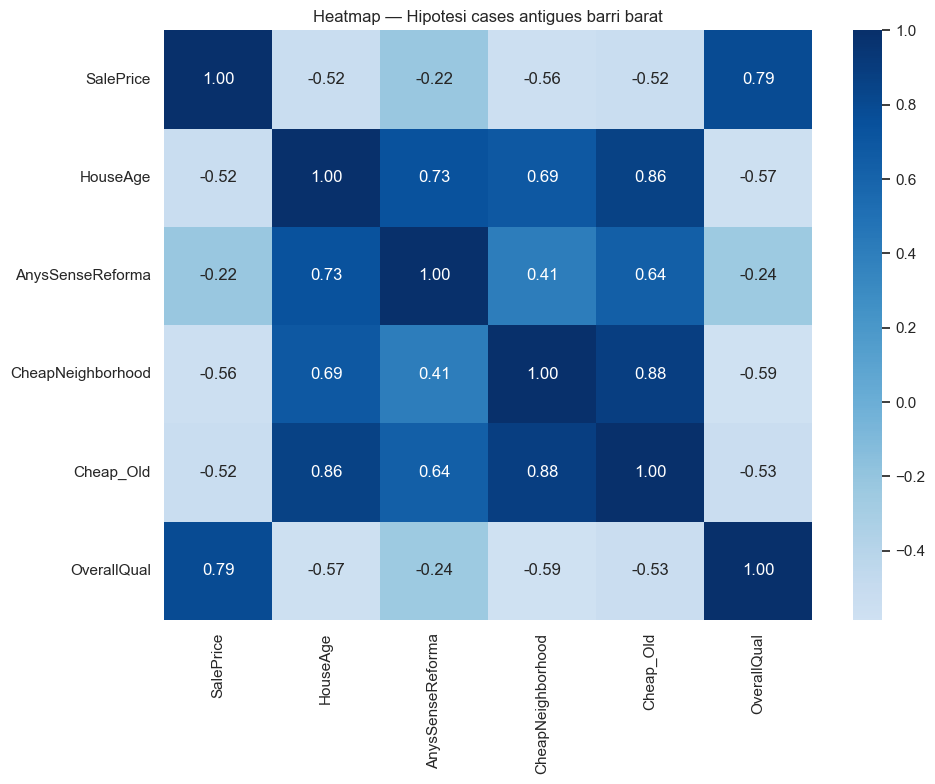

In [21]:
# Creem les variables temporalment per l'EDA
train_eda = train.copy()
train_eda['HouseAge'] = 2010 - train_eda['YearBuilt']
train_eda['AnysSenseReforma'] = train_eda['YearRemodAdd'] - train_eda['YearBuilt']
train_eda['CheapNeighborhood'] = train_eda['Neighborhood'].isin(
    ['MeadowV', 'IDOTRR', 'BrDale', 'OldTown', 'Edwards', 
     'BrkSide', 'Sawyer', 'Blueste', 'SWISU', 'NAmes']
).astype(int)
train_eda['Cheap_Old'] = train_eda['CheapNeighborhood'] * train_eda['HouseAge']

# Heatmap
cols = ['SalePrice', 'HouseAge', 'AnysSenseReforma', 'CheapNeighborhood', 'Cheap_Old', 'OverallQual']

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_eda[cols].corr(),
    annot=True, fmt='.2f',
    cmap='Blues',
    center=0
)
plt.title('Heatmap — Hipotesi cases antigues barri barat')
plt.tight_layout()
plt.show()

In [22]:
for col in cols:
    if col != 'SalePrice':
        corr = train_eda[col].corr(train_eda['SalePrice'])
        print(f"{col:25} -> SalePrice: {corr:.3f}")

HouseAge                  -> SalePrice: -0.523
AnysSenseReforma          -> SalePrice: -0.218
CheapNeighborhood         -> SalePrice: -0.559
Cheap_Old                 -> SalePrice: -0.518
OverallQual               -> SalePrice: 0.791


In [23]:
groga_baix_df = train[groga_baix].describe()
resta_df = train[~groga_baix].describe()

# Diferencia entre les dues poblacions
diff = (groga_baix_df.loc['mean'] - resta_df.loc['mean']).sort_values()
print(diff.head(15))  # les que més difereixen per baix

SalePrice      -72648.027102
LotArea         -1518.347212
BsmtFinSF1       -279.892424
TotalBsmtSF      -245.015185
GarageArea       -159.299220
1stFlrSF          -50.724577
WoodDeckSF        -50.647227
MasVnrArea        -48.562266
YearBuilt         -35.199480
GarageYrBlt       -22.353848
BsmtFinSF2        -18.884533
OpenPorchSF       -16.993662
YearRemodAdd      -16.844341
ScreenPorch       -13.809981
LotFrontage        -5.516789
Name: mean, dtype: float64


In [24]:
cols_poor = ['HouseAge', 'CheapNeighborhood', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'LotArea']

for col in cols_poor:
    corr = train_eda[col].corr(train_eda['SalePrice'])
    print(f"{col:20} -> SalePrice: {corr:.3f}")

HouseAge             -> SalePrice: -0.523
CheapNeighborhood    -> SalePrice: -0.559
TotalBsmtSF          -> SalePrice: 0.614
GarageArea           -> SalePrice: 0.623
1stFlrSF             -> SalePrice: 0.606
LotArea              -> SalePrice: 0.264


In [25]:
train_eda['PoorHouse'] = (
    train_eda['HouseAge'] * 
    train_eda['CheapNeighborhood'] * 
    (1 / train_eda['TotalBsmtSF'].clip(1)) * 
    (1 / train_eda['GarageArea'].clip(1)) * 
    (1 / train_eda['1stFlrSF'].clip(1))
)

corr = train_eda['PoorHouse'].corr(train_eda['SalePrice'])
print(f"PoorHouse -> SalePrice: {corr:.3f}")

PoorHouse -> SalePrice: -0.083


In [26]:
# Normalitzem cada variable entre 0 i 1 primer
from sklearn.preprocessing import MinMaxScaler

scaler_eda = MinMaxScaler()
cols_norm = ['HouseAge', 'CheapNeighborhood', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']
train_norm = pd.DataFrame(scaler_eda.fit_transform(train_eda[cols_norm]), columns=cols_norm)

# PoorHouse com a suma ponderada pels pesos de correlació
train_eda['PoorHouse2'] = (
    train_norm['HouseAge'] * 0.523 +
    train_norm['CheapNeighborhood'] * 0.559 -
    train_norm['TotalBsmtSF'] * 0.614 -
    train_norm['GarageArea'] * 0.623 -
    train_norm['1stFlrSF'] * 0.606
)

corr = train_eda['PoorHouse2'].corr(train_eda['SalePrice'])
print(f"PoorHouse2 -> SalePrice: {corr:.3f}")

PoorHouse2 -> SalePrice: -0.715


In [27]:
# Les 10 cases amb PoorHouse2 més alt (les més "pobres")
top_poor = train_eda.nlargest(10, 'PoorHouse2')[['SalePrice', 'Neighborhood', 'YearBuilt', 'GarageArea', 'TotalBsmtSF']]
print(top_poor)

      SalePrice Neighborhood  YearBuilt  GarageArea  TotalBsmtSF
1137      94000       Sawyer       1875           0          780
1349     122000      OldTown       1872           0          684
520      106250      OldTown       1900           0            0
705       55000       IDOTRR       1930           0            0
968       37900      OldTown       1910           0          600
386       81000      Edwards       1910           0          658
750       96500      OldTown       1910           0          576
528       86000      Edwards       1920           0          528
533       39300      BrkSide       1946           0            0
155       79000      Edwards       1924           0          572


In [28]:
groga_dalt_df = train[groga_dalt]
diff_dalt = (groga_dalt_df.describe().loc['mean'] - train.describe().loc['mean']).sort_values(ascending=False)
print(diff_dalt.head(15))

SalePrice       77299.743041
LotArea          3422.836040
BsmtFinSF1        351.978595
TotalBsmtSF       337.578182
1stFlrSF          242.358020
GarageArea        150.180168
MasVnrArea         99.314738
WoodDeckSF         47.579907
YearBuilt          23.388680
GarageYrBlt        17.255375
YearRemodAdd       15.424323
OpenPorchSF         9.507665
ScreenPorch         5.427591
LotFrontage         4.450042
GrLivArea           4.353095
Name: mean, dtype: float64


In [29]:
print(train[groga_dalt]['SaleCondition'].value_counts())
print(train[groga_dalt]['Neighborhood'].value_counts().head(10))

SaleCondition
Normal     95
Partial    34
Abnorml     1
Family      1
Name: count, dtype: int64
Neighborhood
NridgHt    27
CollgCr    26
Somerst    16
Timber     11
StoneBr     9
ClearCr     6
Mitchel     6
Crawfor     5
NAmes       4
NoRidge     4
Name: count, dtype: int64


In [30]:
train_eda['RichHouse'] = (
    train_norm['GarageArea'] * 0.623 +
    train_norm['TotalBsmtSF'] * 0.614 +
    train_norm['1stFlrSF'] * 0.606 -
    train_norm['HouseAge'] * 0.523 -
    train_norm['CheapNeighborhood'] * 0.559
)

corr = train_eda['RichHouse'].corr(train_eda['SalePrice'])
print(f"RichHouse -> SalePrice: {corr:.3f}")

RichHouse -> SalePrice: 0.715


In [31]:
cols_rich = ['GarageArea', 'TotalBsmtSF', '1stFlrSF', 'HouseAge', 'CheapNeighborhood', 'RichHouse', 'PoorHouse2']

for col in cols_rich:
    corr = train_eda[col].corr(train_eda['SalePrice'])
    print(f"{col:20} -> SalePrice: {corr:.3f}")

GarageArea           -> SalePrice: 0.623
TotalBsmtSF          -> SalePrice: 0.614
1stFlrSF             -> SalePrice: 0.606
HouseAge             -> SalePrice: -0.523
CheapNeighborhood    -> SalePrice: -0.559
RichHouse            -> SalePrice: 0.715
PoorHouse2           -> SalePrice: -0.715


In [32]:
train_eda['ExpensiveNeighborhood'] = train_eda['Neighborhood'].isin(
    ['NridgHt', 'StoneBr', 'NoRidge', 'Timber', 'Somerst']
).astype(int)

corr = train_eda['ExpensiveNeighborhood'].corr(train_eda['SalePrice'])
print(f"ExpensiveNeighborhood -> SalePrice: {corr:.3f}")

ExpensiveNeighborhood -> SalePrice: 0.583


In [33]:
train_norm2 = pd.DataFrame(
    scaler_eda.fit_transform(train_eda[['HouseAge', 'CheapNeighborhood', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'ExpensiveNeighborhood']]),
    columns=['HouseAge', 'CheapNeighborhood', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'ExpensiveNeighborhood']
)

train_eda['RichHouse'] = (
    train_norm2['GarageArea'] * 0.623 +
    train_norm2['TotalBsmtSF'] * 0.614 +
    train_norm2['1stFlrSF'] * 0.606 -
    train_norm2['HouseAge'] * 0.523 -
    train_norm2['CheapNeighborhood'] * 0.559 +
    train_norm2['ExpensiveNeighborhood'] * 0.583
)

corr_rich = train_eda['RichHouse'].corr(train_eda['SalePrice'])
print(f"RichHouse amb barri car -> SalePrice: {corr_rich:.3f}")

RichHouse amb barri car -> SalePrice: 0.754


In [34]:
train_eda['PoorHouse2'] = (
    train_norm2['HouseAge'] * 0.523 +
    train_norm2['CheapNeighborhood'] * 0.559 -
    train_norm2['TotalBsmtSF'] * 0.614 -
    train_norm2['GarageArea'] * 0.623 -
    train_norm2['1stFlrSF'] * 0.606 -
    train_norm2['ExpensiveNeighborhood'] * 0.583
)

corr_poor = train_eda['PoorHouse2'].corr(train_eda['SalePrice'])
print(f"PoorHouse2 actualitzat -> SalePrice: {corr_poor:.3f}")

PoorHouse2 actualitzat -> SalePrice: -0.754


In [35]:
print(f"Correlacio PoorHouse2 vs RichHouse: {train_eda['PoorHouse2'].corr(train_eda['RichHouse']):.3f}")

Correlacio PoorHouse2 vs RichHouse: -1.000


In [36]:
anomalia_dalt = train['SalePrice'] > y_pred_train * 1.6

print(f"Anomalies per DALT: {anomalia_dalt.sum()} cases ({anomalia_dalt.mean()*100:.1f}%)")

print(train[anomalia_dalt][['SalePrice', 'Neighborhood', 'SaleCondition', 
                              'OverallQual', 'YearBuilt', 'GrLivArea']]\
     .sort_values('SalePrice', ascending=False))

Anomalies per DALT: 31 cases (2.1%)
      SalePrice Neighborhood SaleCondition  OverallQual  YearBuilt  GrLivArea
691      755000      NoRidge        Normal           10       1994       4316
1182     745000      NoRidge       Abnorml           10       1996       4476
1169     625000      NoRidge        Normal           10       1995       3627
898      611657      NridgHt       Partial            9       2009       2364
803      582933      NridgHt       Partial            9       2008       2822
1046     556581      StoneBr       Partial            9       2005       2868
440      555000      NridgHt        Normal           10       2008       2402
178      501837      StoneBr       Partial            9       2008       2234
1243     465000      NridgHt       Partial           10       2006       2076
591      451950      NridgHt        Normal           10       2008       2296
473      440000      NridgHt       Partial            8       2006       1976
664      423000      Somerst

In [37]:
print(f"Anomalies dalt capturades per RichHouse alt:")
print(train_eda[anomalia_dalt]['RichHouse'].describe())

Anomalies dalt capturades per RichHouse alt:
count    31.000000
mean      1.275470
std       0.235158
min       0.548247
25%       1.275736
50%       1.323285
75%       1.396275
max       1.574596
Name: RichHouse, dtype: float64


In [38]:
print(f"RichHouse mitjana anomalies dalt: {train_eda[anomalia_dalt]['RichHouse'].mean():.3f}")
print(f"RichHouse mitjana zona normal:    {train_eda[normal]['RichHouse'].mean():.3f}")
print(f"RichHouse mitjana dataset sencer: {train_eda['RichHouse'].mean():.3f}")

RichHouse mitjana anomalies dalt: 1.275
RichHouse mitjana zona normal:    0.116
RichHouse mitjana dataset sencer: 0.134


In [39]:
anomalia_baix = train['SalePrice'] < y_pred_train * 0.4

print(f"Anomalies per BAIX: {anomalia_baix.sum()} cases ({anomalia_baix.mean()*100:.1f}%)")

print(train[anomalia_baix][['SalePrice', 'Neighborhood', 'SaleCondition', 
                              'OverallQual', 'YearBuilt', 'GrLivArea']]\
     .sort_values('SalePrice'))

Anomalies per BAIX: 7 cases (0.5%)
      SalePrice Neighborhood SaleCondition  OverallQual  YearBuilt  GrLivArea
968       37900      OldTown       Abnorml            3       1910        968
30        40000       IDOTRR        Normal            4       1920       1317
410       60000      Edwards       Abnorml            5       1958       1276
1062      90000      OldTown        Normal            5       1900       2337
198      104000      OldTown       Abnorml            6       1912       2229
1292     107500      OldTown        Normal            5       1892       2372
1298     160000      Edwards       Partial           10       2008       5642
